# 09 — Comparación de Baselines

**Objetivo**: demostrar que el enfoque WiFi + XGBoost supera a alternativas
más simples, y cuantificar exactamente qué aporta cada componente.

**Pregunta que responde este notebook**:  
> *¿Por qué necesitamos un simulador + XGBoost si podemos predecir el consumo con una regresión simple?*

**Escalera de modelos** (cada nivel añade un componente):

| Modelo | Features | Qué prueba |
|--------|----------|------------|
| B0 | ninguna (media global) | cota inferior absoluta |
| B1 | mes + hora + día_semana | patrón temporal naive |
| B2 | temperatura | solo clima |
| B3 | temperatura + tiempo cíclico | clima + ritmo horario |
| **B4** | **B3 + WiFi (ocupación)** | **← el WiFi aporta señal real** |
| B5 | B4 con XGBoost (no-lineal) | modelo no-lineal sin feature eng. |
| B6 | Modelo B final (todas las features) | pipeline completo |

El salto **B3 → B4** es el argumento central del TFG.  
El salto **B4 → B6** justifica el feature engineering avanzado.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

DATA_PROCESSED = Path('../data/processed')
FIGURES        = Path('../outputs/figures')
REPORTS        = Path('../outputs/reports')
FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
RANDOM_SEED = 42
print('OK')

OK


In [45]:
# ── Cargar el CSV mergeado ────────────────────────────────────────────────────
# Columnas esperadas:
# Timestamp, Consumo_kWh, Temperatura, Lluvia, Aules_Ocupades,
# Ocupacio_Percent, tipus_dia, Dia_Semana_Num, Dia_Semana, Ocupacion_Simulada

CSV_PATH = DATA_PROCESSED / 'dataset_smart_campus_master.csv'   # ← CAMBIA ESTO

df = pd.read_csv(CSV_PATH, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Dataset: {df.shape[0]:,} horas × {df.shape[1]} columnas')
print(f'Rango:   {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')
print(f'Columnas: {df.columns.tolist()}')
print(f'\nNulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset: 8,784 horas × 10 columnas
Rango:   2024-01-01 → 2025-01-01
Columnas: ['Timestamp', 'Consumo_kWh', 'Temperatura', 'Lluvia', 'Aules_Ocupades', 'Ocupacio_Percent', 'tipus_dia', 'Dia_Semana_Num', 'Dia_Semana', 'Ocupacion_Simulada']

Nulos por columna:
Series([], dtype: int64)


In [46]:
# ── Features temporales básicas ───────────────────────────────────────────────
df['hora']       = df['Timestamp'].dt.hour
df['mes']        = df['Timestamp'].dt.month
df['dia_semana'] = df['Timestamp'].dt.dayofweek   # 0=Lun, 6=Dom

# Encoding cíclico (sin/cos) — captura continuidad 23h→0h, Dic→Ene
df['hora_sin']    = np.sin(2 * np.pi * df['hora']       / 24)
df['hora_cos']    = np.cos(2 * np.pi * df['hora']       / 24)
# df['mes_sin']     = np.sin(2 * np.pi * df['mes']        / 12)
# df['mes_cos']     = np.cos(2 * np.pi * df['mes']        / 12)
df['diasem_sin']  = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['diasem_cos']  = np.cos(2 * np.pi * df['dia_semana'] / 7)

# One-hot del tipo de día (para B5 y B6)
tipusdia_dummies = pd.get_dummies(df['tipus_dia'], prefix='td')
df = pd.concat([df, tipusdia_dummies], axis=1)
tipus_cols = tipusdia_dummies.columns.tolist()

# Limpiar nulos en target
df = df.dropna(subset=['Consumo_kWh', 'Ocupacion_Simulada', 'Temperatura'])
print(f'Filas tras dropna: {len(df):,}')

Filas tras dropna: 8,784


In [47]:
# ── Split temporal estricto 80/20 ─────────────────────────────────────────────
# Train: enero–septiembre  |  Test: octubre–diciembre
# MISMO split que el modelo principal — resultados comparables

split_idx = int(len(df) * 0.80)
df_tr = df.iloc[:split_idx].copy()
df_te = df.iloc[split_idx:].copy()

y_tr = df_tr['Consumo_kWh']
y_te = df_te['Consumo_kWh']

print(f'Train: {len(df_tr):,} horas  '
      f'({df_tr["Timestamp"].min().date()} → {df_tr["Timestamp"].max().date()})')
print(f'Test:  {len(df_te):,} horas  '
      f'({df_te["Timestamp"].min().date()} → {df_te["Timestamp"].max().date()})')
print(f'\nConsumo real — test set:')
print(f'  Media: {y_te.mean():.1f} kWh  |  Std: {y_te.std():.1f} kWh')
print(f'  Min:   {y_te.min():.1f} kWh  |  Max: {y_te.max():.1f} kWh')

Train: 7,027 horas  (2024-01-01 → 2024-10-19)
Test:  1,757 horas  (2024-10-19 → 2025-01-01)

Consumo real — test set:
  Media: 186.2 kWh  |  Std: 111.3 kWh
  Min:   87.0 kWh  |  Max: 441.0 kWh


## Evaluación de baselines

In [48]:
resultados = []

def evaluar(nombre, pred_tr, pred_te, feats_desc, color='C0'):
    """Registra métricas train y test para un modelo."""
    r = {
        'Modelo':     nombre,
        'Features':   feats_desc,
        'R²_train':   r2_score(y_tr, pred_tr),
        'R²_test':    r2_score(y_te, pred_te),
        'MAE_test':   mean_absolute_error(y_te, pred_te),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, pred_te)),
        'color':      color,
    }
    resultados.append(r)
    print(f"{nombre:45s}  R²={r['R²_test']:.4f}  MAE={r['MAE_test']:.1f} kWh")
    return pred_te


print('Evaluando modelos...')
print('─' * 70)

# ── B0: Media global ──────────────────────────────────────────────────────────
media_global = y_tr.mean()
evaluar(
    'B0 — Media global',
    np.full(len(y_tr), media_global),
    np.full(len(y_te), media_global),
    'ninguna', color='#BDBDBD'
)

# ── B1: Media por (mes, hora, dia_semana) ─────────────────────────────────────
key_b1 = ['mes', 'hora', 'dia_semana']
lookup_b1 = df_tr.groupby(key_b1)['Consumo_kWh'].mean()

def predecir_lookup(df_in, lookup, key, fallback=media_global):
    return df_in.set_index(key).index.map(lookup).fillna(fallback).values

evaluar(
    'B1 — Media (mes × hora × día_semana)',
    predecir_lookup(df_tr, lookup_b1, key_b1),
    predecir_lookup(df_te, lookup_b1, key_b1),
    'mes, hora, día_semana', color='#9E9E9E'
)

# ── B2: Regresión lineal — solo temperatura ───────────────────────────────────
f_b2 = ['Temperatura']
lr_b2 = LinearRegression().fit(df_tr[f_b2], y_tr)
evaluar(
    'B2 — LR (temperatura)',
    lr_b2.predict(df_tr[f_b2]),
    lr_b2.predict(df_te[f_b2]),
    'Temperatura', color='#90CAF9'
)

# ── B3: LR — temperatura + tiempo cíclico ────────────────────────────────────
f_b3 = ['Temperatura', 'hora_sin', 'hora_cos',
         'diasem_sin', 'diasem_cos']
lr_b3 = LinearRegression().fit(df_tr[f_b3], y_tr)
evaluar(
    'B3 — LR (temp + tiempo cíclico)',
    lr_b3.predict(df_tr[f_b3]),
    lr_b3.predict(df_te[f_b3]),
    'temp + hora/dow (sin/cos)', color='#42A5F5'
)

# ── B4: LR — B3 + WiFi ───────────────────────────────────────────────────────
# ESTE ES EL SALTO CLAVE: añadir Ocupacion_Simulada (WiFi)
f_b4 = f_b3 + ['Ocupacion_Simulada']
lr_b4 = LinearRegression().fit(df_tr[f_b4], y_tr)
pred_b4_te = evaluar(
    'B4 — LR (temp + tiempo + WiFi)  ★',
    lr_b4.predict(df_tr[f_b4]),
    lr_b4.predict(df_te[f_b4]),
    'temp + tiempo + Ocupacion_Simulada', color='#FF8F00'
)

# ── B5: XGBoost simple — mismas features que B4 ──────────────────────────────
xgb_b5 = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                       random_state=RANDOM_SEED, n_jobs=-1,
                       objective='reg:squarederror')
xgb_b5.fit(df_tr[f_b4], y_tr)
evaluar(
    'B5 — XGBoost (temp + tiempo + WiFi)',
    xgb_b5.predict(df_tr[f_b4]),
    xgb_b5.predict(df_te[f_b4]),
    'igual que B4 pero no-lineal', color='#F4511E'
)

# ── B6: XGBoost — todas las features del CSV ─────────────────────────────────
f_b6 = (['Temperatura', 'Lluvia', 'Ocupacion_Simulada',
          'hora_sin', 'hora_cos',
          'diasem_sin', 'diasem_cos'] + tipus_cols)
# Añadir Aules_Ocupades y Ocupacio_Percent si están disponibles
#for col in ['Aules_Ocupades', 'Ocupacio_Percent']:
#    if col in df.columns:
#        f_b6.append(col)

xgb_b6 = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=RANDOM_SEED, n_jobs=-1,
                       objective='reg:squarederror')
xgb_b6.fit(df_tr[f_b6], y_tr)
evaluar(
    'B6 — XGBoost (todas las features CSV)',
    xgb_b6.predict(df_tr[f_b6]),
    xgb_b6.predict(df_te[f_b6]),
    'todas las features disponibles', color='#C62828'
)

# ── B7 (opcional): Cargar tu modelo final guardado ───────────────────────────
# Si tienes el Modelo B guardado en disco, descomenta esto:
# import joblib
# xgb_final = joblib.load('../outputs/models/xgb_modelo_B.pkl')
# feat_final = joblib.load('../outputs/models/feat_modelo_B.pkl')
# evaluar(
#     'B7 — Modelo B final (pipeline completo)',
#     xgb_final.predict(df_tr[feat_final]),
#     xgb_final.predict(df_te[feat_final]),
#     'features completas + lags + feature engineering', color='#6A1B9A'
# )

print('─' * 70)
print('✅ Evaluación completada')

Evaluando modelos...
──────────────────────────────────────────────────────────────────────
B0 — Media global                              R²=-0.0006  MAE=95.6 kWh
B1 — Media (mes × hora × día_semana)           R²=0.2014  MAE=78.5 kWh
B2 — LR (temperatura)                          R²=0.0207  MAE=93.2 kWh
B3 — LR (temp + tiempo cíclico)                R²=0.5342  MAE=61.4 kWh
B4 — LR (temp + tiempo + WiFi)  ★              R²=0.8353  MAE=35.2 kWh
B5 — XGBoost (temp + tiempo + WiFi)            R²=0.9229  MAE=20.5 kWh
B6 — XGBoost (todas las features CSV)          R²=0.9443  MAE=17.2 kWh
──────────────────────────────────────────────────────────────────────
✅ Evaluación completada


## Tabla resumen

In [49]:
df_res = pd.DataFrame(resultados)
df_res['GAP_R²_vs_anterior'] = df_res['R²_test'].diff().round(4)

print('\n══════════════════════════════════════════════════════════════════')
print('TABLA COMPARATIVA DE BASELINES')
print('══════════════════════════════════════════════════════════════════')
print(df_res[['Modelo','R²_train','R²_test','MAE_test',
              'RMSE_test','GAP_R²_vs_anterior']].to_string(index=False))

# Identificar el salto del WiFi (B3 → B4)
r2_b3 = df_res.loc[df_res['Modelo'].str.startswith('B3'), 'R²_test'].values[0]
r2_b4 = df_res.loc[df_res['Modelo'].str.startswith('B4'), 'R²_test'].values[0]
salto_wifi = r2_b4 - r2_b3

mae_b3 = df_res.loc[df_res['Modelo'].str.startswith('B3'), 'MAE_test'].values[0]
mae_b4 = df_res.loc[df_res['Modelo'].str.startswith('B4'), 'MAE_test'].values[0]

print(f'\n🔑 APORTACIÓN DEL WiFi (B3 → B4):')
print(f'   ΔR²  = +{salto_wifi:.4f}  ({salto_wifi*100:.1f} puntos)')
print(f'   ΔMAE = -{mae_b3 - mae_b4:.1f} kWh  ({(mae_b3-mae_b4)/mae_b3*100:.1f}% de reducción)')

df_res.to_csv(REPORTS / 'tabla_baselines.csv', index=False)
print(f'\n✅ Tabla guardada en outputs/reports/tabla_baselines.csv')


══════════════════════════════════════════════════════════════════
TABLA COMPARATIVA DE BASELINES
══════════════════════════════════════════════════════════════════
                               Modelo  R²_train   R²_test  MAE_test  RMSE_test  GAP_R²_vs_anterior
                    B0 — Media global  0.000000 -0.000606 95.578924 111.292724                 NaN
 B1 — Media (mes × hora × día_semana)  0.886865  0.201386 78.536939  99.426883              0.2020
                B2 — LR (temperatura)  0.002676  0.020659 93.157602 110.103766             -0.1807
      B3 — LR (temp + tiempo cíclico)  0.572917  0.534246 61.396061  75.930040              0.5136
    B4 — LR (temp + tiempo + WiFi)  ★  0.789588  0.835306 35.223721  45.151770              0.3011
  B5 — XGBoost (temp + tiempo + WiFi)  0.939889  0.922896 20.505180  30.894005              0.0876
B6 — XGBoost (todas las features CSV)  0.974338  0.944346 17.156551  26.247262              0.0215

🔑 APORTACIÓN DEL WiFi (B3 → B4):
   ΔR²  

## Figura principal — escalera de R²

C:\Users\jordi\AppData\Local\Temp\ipykernel_34820\1650632177.py:80: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipykernel_34820\1650632177.py:81: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES / 'baselines_escalera.png', dpi=150, bbox_inches='tight')
c:\Users\jordi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


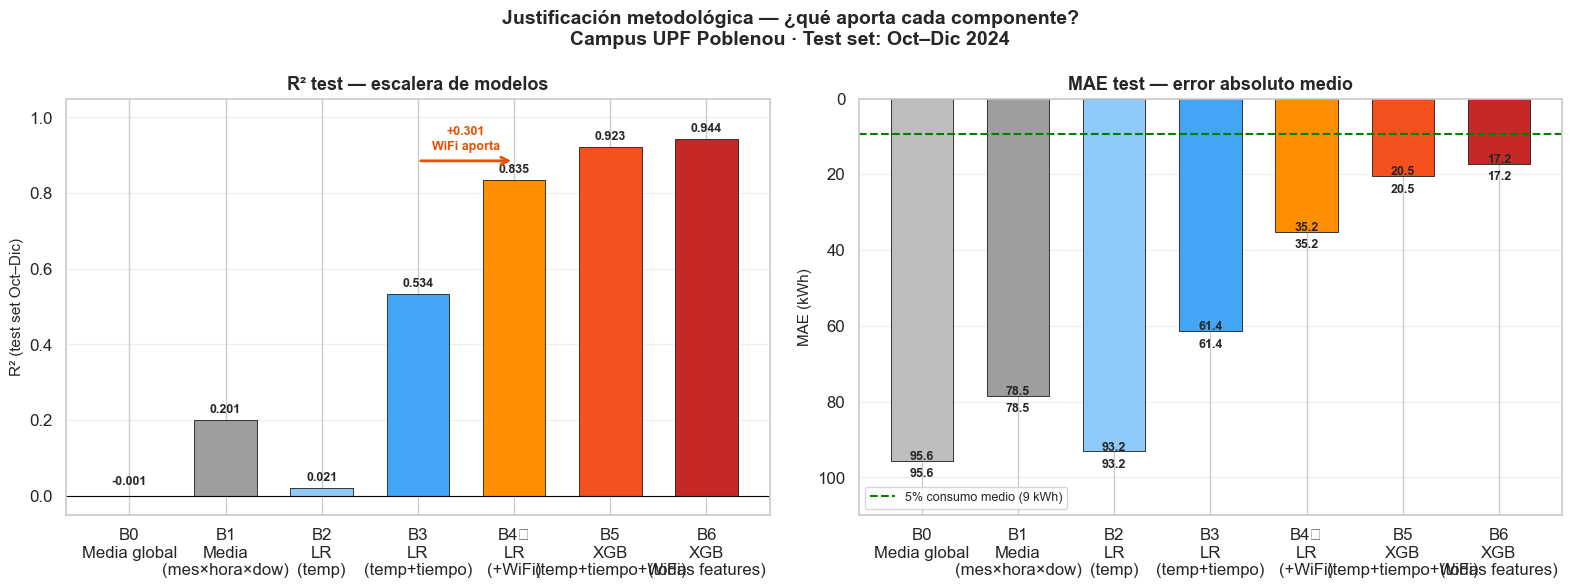

✅ Guardado: baselines_escalera.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_cortos = [
    'B0\nMedia global',
    'B1\nMedia\n(mes×hora×dow)',
    'B2\nLR\n(temp)',
    'B3\nLR\n(temp+tiempo)',
    'B4★\nLR\n(+WiFi)',
    'B5\nXGB\n(temp+tiempo+WiFi)',
    'B6\nXGB\n(todas features)',
]
n = len(df_res)
nombres_cortos = modelos_cortos[:n]
colores = df_res['color'].tolist()
r2_vals = df_res['R²_test'].tolist()
mae_vals = df_res['MAE_test'].tolist()

# ── Panel izquierdo: R² test ──────────────────────────────────────────────────
bars = axes[0].bar(nombres_cortos, r2_vals, color=colores,
                    edgecolor='k', linewidth=0.6, width=0.65)

# Anotar valores
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  max(val + 0.01, 0.02),
                  f'{val:.3f}',
                  ha='center', va='bottom', fontsize=9, fontweight='bold')

# Flecha y anotación del salto WiFi
idx_b3 = next(i for i, m in enumerate(df_res['Modelo']) if m.startswith('B3'))
idx_b4 = next(i for i, m in enumerate(df_res['Modelo']) if m.startswith('B4'))
y_flecha = max(r2_vals[idx_b3], r2_vals[idx_b4]) + 0.07
axes[0].annotate(
    '', xy=(idx_b4, y_flecha - 0.02), xytext=(idx_b3, y_flecha - 0.02),
    arrowprops=dict(arrowstyle='->', color='#E65100', lw=2)
)
axes[0].text((idx_b3 + idx_b4) / 2, y_flecha + 0.01,
              f'+{salto_wifi:.3f}\nWiFi aporta',
              ha='center', fontsize=9, color='#E65100', fontweight='bold')

axes[0].set_ylim(min(0, min(r2_vals) - 0.05), 1.05)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('R² test — escalera de modelos', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² (test set Oct–Dic)', fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# ── Panel derecho: MAE test ───────────────────────────────────────────────────
bars2 = axes[1].bar(nombres_cortos, mae_vals, color=colores,
                     edgecolor='k', linewidth=0.6, width=0.65)

for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  val + 0.5, f'{val:.1f}',
                  ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de referencia: "un 5% del consumo medio"
consumo_medio_test = y_te.mean()
ref_5pct = consumo_medio_test * 0.05
axes[1].axhline(ref_5pct, color='green', ls='--', lw=1.5,
                 label=f'5% consumo medio ({ref_5pct:.0f} kWh)')
axes[1].legend(fontsize=9)

axes[1].set_title('MAE test — error absoluto medio', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE (kWh)', fontsize=11)
axes[1].grid(alpha=0.3, axis='y')
axes[1].invert_yaxis()   # menor MAE = mejor → barra más larga hacia abajo
axes[1].set_ylim(max(mae_vals) * 1.15, 0)

# Re-anotar con eje invertido
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  val + max(mae_vals)*0.02, f'{val:.1f}',
                  ha='center', va='top', fontsize=9, fontweight='bold')

plt.suptitle(
    'Justificación metodológica — ¿qué aporta cada componente?\n'
    'Campus UPF Poblenou · Test set: Oct–Dic 2024',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES / 'baselines_escalera.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: baselines_escalera.png')

## Figura secundaria — scatter pred vs real para cada baseline

C:\Users\jordi\AppData\Local\Temp\ipykernel_34820\4179372290.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jordi\AppData\Local\Temp\ipykernel_34820\4179372290.py:28: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES / 'baselines_scatter.png', dpi=150, bbox_inches='tight')
c:\Users\jordi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


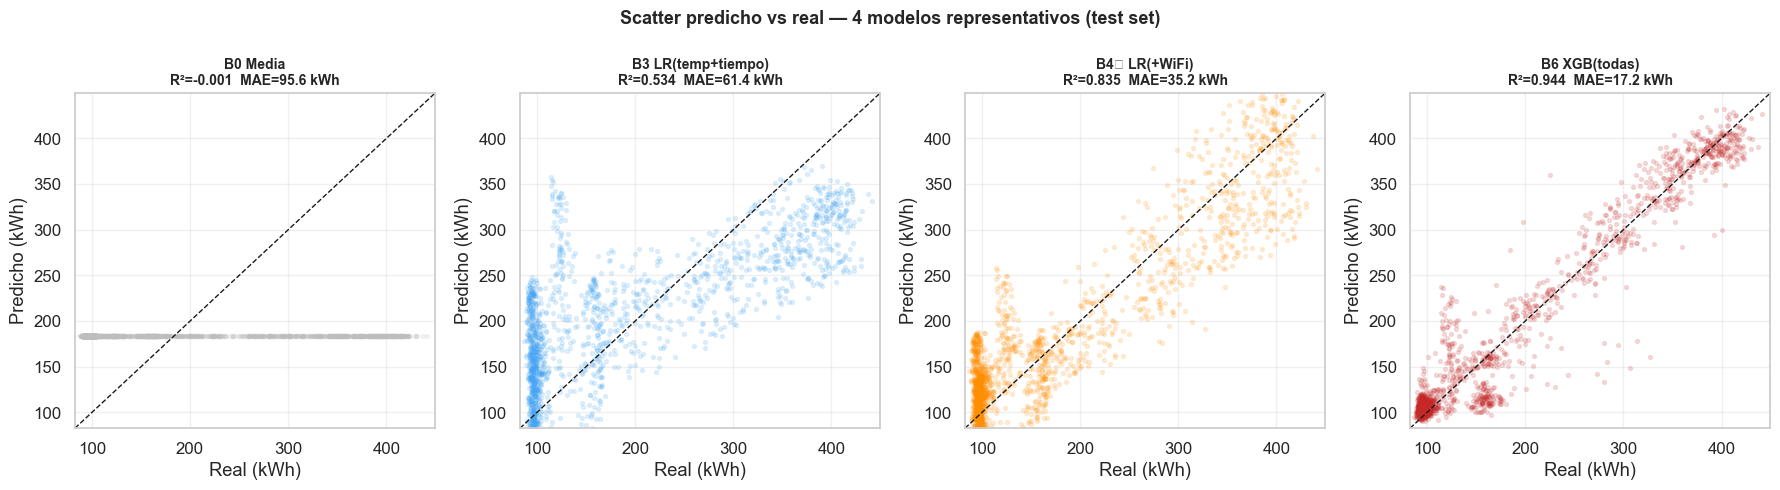

✅ Guardado: baselines_scatter.png


In [55]:
# Regenerar predicciones para el scatter
preds_te = {
    'B0 Media':              np.full(len(y_te), media_global),
    'B3 LR(temp+tiempo)':   lr_b3.predict(df_te[f_b3]),
    'B4★ LR(+WiFi)':        lr_b4.predict(df_te[f_b4]),
    'B6 XGB(todas)':        xgb_b6.predict(df_te[f_b6]),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colores_sc = ['#BDBDBD', '#42A5F5', '#FF8F00', '#C62828']

lim = [y_te.min() * 0.95, y_te.max() * 1.02]

for ax, (nombre, pred), color in zip(axes, preds_te.items(), colores_sc):
    r2_val = r2_score(y_te, pred)
    mae_val = mean_absolute_error(y_te, pred)
    ax.scatter(y_te, pred, alpha=0.15, s=8, color=color)
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f'{nombre}\nR²={r2_val:.3f}  MAE={mae_val:.1f} kWh',
                  fontsize=10, fontweight='bold')
    ax.set_xlabel('Real (kWh)'); ax.set_ylabel('Predicho (kWh)')
    ax.grid(alpha=0.3)

plt.suptitle('Scatter predicho vs real — 4 modelos representativos (test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'baselines_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: baselines_scatter.png')

## Figura terciaria — coeficientes del modelo lineal B4

Muestra que el coeficiente de `Ocupacion_Simulada` es positivo y significativo,
confirmando que el WiFi tiene una relación lineal directa con el consumo.

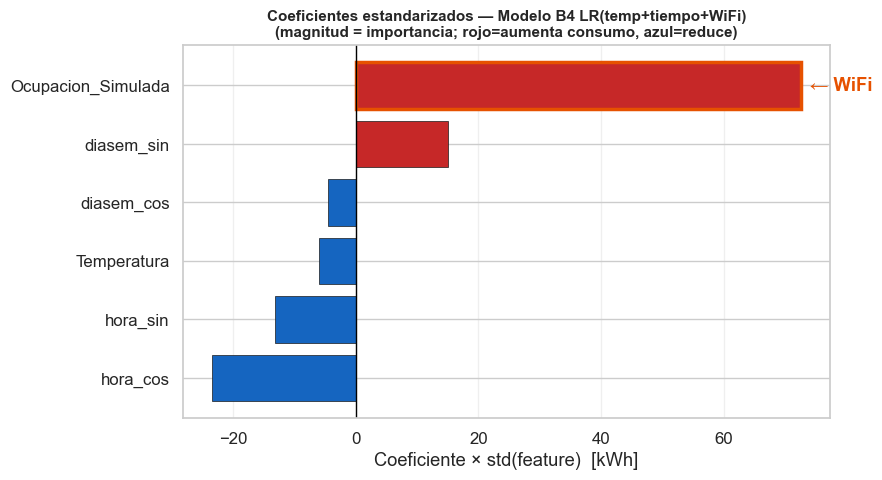

✅ Guardado: baselines_coef_b4.png


In [52]:
coef_b4 = pd.Series(lr_b4.coef_, index=f_b4).sort_values(key=abs, ascending=False)

# Normalizar por std para comparar magnitudes
std_feats = df_tr[f_b4].std()
coef_std  = (coef_b4 * std_feats).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colores_coef = ['#C62828' if v > 0 else '#1565C0' for v in coef_std.values]
ax.barh(coef_std.index, coef_std.values, color=colores_coef,
         edgecolor='k', linewidth=0.5)
ax.axvline(0, color='black', lw=1)

# Destacar el WiFi
if 'Ocupacion_Simulada' in coef_std.index:
    idx_wifi = list(coef_std.index).index('Ocupacion_Simulada')
    ax.get_children()[idx_wifi].set_edgecolor('#E65100')
    ax.get_children()[idx_wifi].set_linewidth(2.5)
    ax.text(coef_std['Ocupacion_Simulada'] + abs(coef_std).max()*0.02,
             idx_wifi, '← WiFi', va='center', color='#E65100', fontweight='bold')

ax.set_title('Coeficientes estandarizados — Modelo B4 LR(temp+tiempo+WiFi)\n'
              '(magnitud = importancia; rojo=aumenta consumo, azul=reduce)',
              fontsize=11, fontweight='bold')
ax.set_xlabel('Coeficiente × std(feature)  [kWh]')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES / 'baselines_coef_b4.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: baselines_coef_b4.png')

## Conclusión para la memoria

In [53]:
r2_b0 = df_res.loc[df_res['Modelo'].str.startswith('B0'), 'R²_test'].values[0]
r2_b2 = df_res.loc[df_res['Modelo'].str.startswith('B2'), 'R²_test'].values[0]
r2_b5 = df_res.loc[df_res['Modelo'].str.startswith('B5'), 'R²_test'].values[0]
r2_b6 = df_res.loc[df_res['Modelo'].str.startswith('B6'), 'R²_test'].values[0]

print('══════════════════════════════════════════════════════════════')
print('RESUMEN PARA LA MEMORIA')
print('══════════════════════════════════════════════════════════════')
print(f"""
La comparación de baselines confirma tres resultados:

1. EL RITMO TEMPORAL EXPLICA LA MAYOR PARTE:
   B0 (media global)         R² = {r2_b0:.3f}  — sin información
   B3 (temp + tiempo)        R² = {r2_b3:.3f}  — solo con hora/mes/dow
   Salto: +{r2_b3-r2_b0:.3f} puntos de R²

2. EL WiFi AÑADE SEÑAL REAL MÁS ALLÁ DEL PATRÓN TEMPORAL:
   B3 (sin WiFi)             R² = {r2_b3:.3f}
   B4 (con WiFi)             R² = {r2_b4:.3f}
   Salto: +{salto_wifi:.3f} puntos de R²  /  -{mae_b3-mae_b4:.1f} kWh de MAE
   → El simulador WiFi captura variabilidad que el calendario no ve.

3. LA NO-LINEALIDAD DE XGBoost APORTA:
   B4 (LR con WiFi)          R² = {r2_b4:.3f}
   B5 (XGB mismas features)  R² = {r2_b5:.3f}
   B6 (XGB todas features)   R² = {r2_b6:.3f}
   → La relación ocupación-consumo no es lineal.
""")
print('══════════════════════════════════════════════════════════════')

══════════════════════════════════════════════════════════════
RESUMEN PARA LA MEMORIA
══════════════════════════════════════════════════════════════

La comparación de baselines confirma tres resultados:

1. EL RITMO TEMPORAL EXPLICA LA MAYOR PARTE:
   B0 (media global)         R² = -0.001  — sin información
   B3 (temp + tiempo)        R² = 0.534  — solo con hora/mes/dow
   Salto: +0.535 puntos de R²

2. EL WiFi AÑADE SEÑAL REAL MÁS ALLÁ DEL PATRÓN TEMPORAL:
   B3 (sin WiFi)             R² = 0.534
   B4 (con WiFi)             R² = 0.835
   Salto: +0.301 puntos de R²  /  -26.2 kWh de MAE
   → El simulador WiFi captura variabilidad que el calendario no ve.

3. LA NO-LINEALIDAD DE XGBoost APORTA:
   B4 (LR con WiFi)          R² = 0.835
   B5 (XGB mismas features)  R² = 0.923
   B6 (XGB todas features)   R² = 0.944
   → La relación ocupación-consumo no es lineal.

══════════════════════════════════════════════════════════════
